# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Geethan Sundaram

**Date:** 9/10/2026

******************* 1. Sample Mean, Covariance, Variance proofs *******************


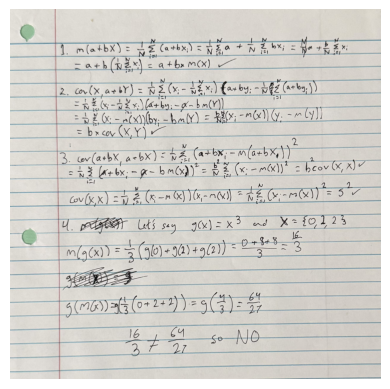

******************* 2.1 Load the dataset *******************
   ID   OPEID               Institution Name          City State  \
0   1  102000  Jacksonville State University  Jacksonville    AL   
1   2  104700                Troy University          Troy    AL   
2   3  105100          University of Alabama    Tuscaloosa    AL   
3   4  105100          University of Alabama    Tuscaloosa    AL   
4   5  105100          University of Alabama    Tuscaloosa    AL   

   Foreign Gift Received Date  Foreign Gift Amount      Gift Type  \
0                       43738               250000  Monetary Gift   
1                       43592               463657       Contract   
2                       43466              3649107       Contract   
3                       43472                 1000       Contract   
4                       43479                49476       Contract   

  Country of Giftor                          Giftor Name  
0             CHINA                                  NaN

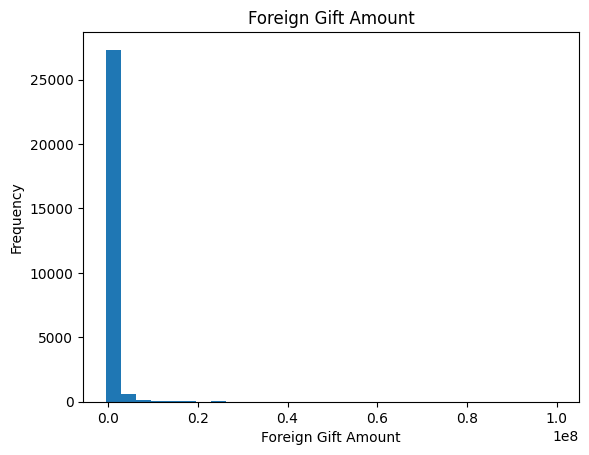


I feel like the distribution of the foreign gift amount is extremely right-skewed. 
The median gift is around $94,615, while the mean is much larger at around $588,233. 
This suggests that a relatively minor number of very large gifts pull the mean higher. 
The max gift is around $100 million, but most gifts are far smaller. 
Interestingly, there are also a few negative gift amounts in the data. 


******************* 2.3 Gift Types *******************
Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         61.209737
Monetary Gift    38.751285
Real Estate       0.038978
Name: proportion, dtype: float64 

******************* 2.4 Log of Foreign Gift Amount *******************


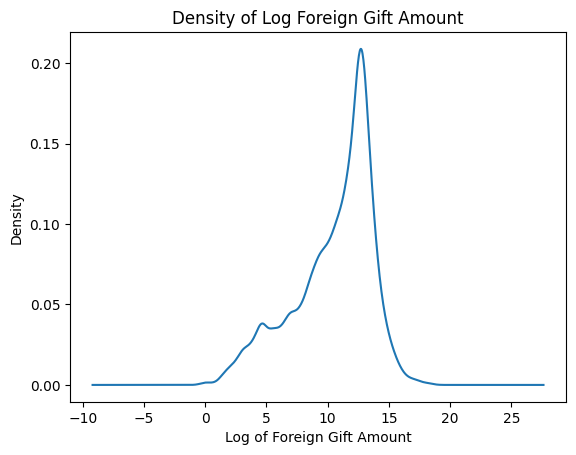

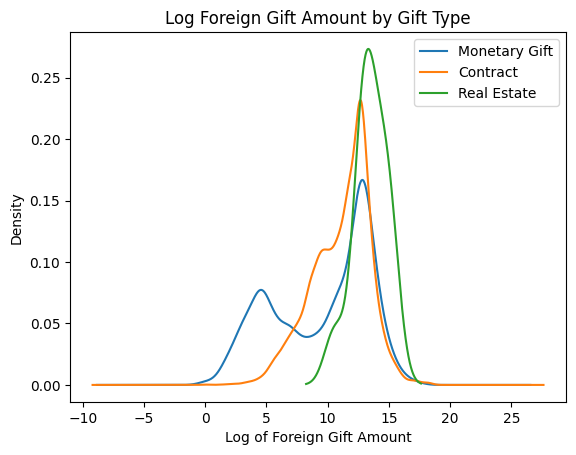


Using the log actually makes the distribution much easier to spot, 
since the very right-skewed nature of the original gift amounts wasn't as intuitive. 
We can see that contracts tend to be concentrated at relatively larger gift amounts than many monetary gifts. 
The monetary gifts actually have a rather wide distribution and include many very small gifts. 
The real estate gifts appear to be located at very high amounts, 
but there are also only 11 real estate observations, so we should be careful about interpreting that one. 


******************* 2.5 Top 15 Countries *******************
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: ID, dtype: int64
Y

In [36]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("******************* 1. Sample Mean, Covariance, Variance proofs *******************")
img = mpimg.imread('IMG_2894.jpg')
plt.imshow(img)
plt.axis('off')
plt.show()

print("******************* 2.1 Load the dataset *******************")
df = pd.read_csv("data/ForeignGifts_edu.csv")

print(df.head(), "\n")

print("******************* 2.2 Foreign Gift Amount *******************")

# Describe Foreign Gift Amount
df["Foreign Gift Amount"].describe()

# Histogram of Foregn Gift Amount
plt.hist(df["Foreign Gift Amount"], bins=30)
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Frequency")
plt.title("Foreign Gift Amount")
plt.show()

print('''
I feel like the distribution of the foreign gift amount is extremely right-skewed. 
The median gift is around $94,615, while the mean is much larger at around $588,233. 
This suggests that a relatively minor number of very large gifts pull the mean higher. 
The max gift is around $100 million, but most gifts are far smaller. 
Interestingly, there are also a few negative gift amounts in the data. \n
''')

print("******************* 2.3 Gift Types *******************")

# Count each gift type
gift_counts = df["Gift Type"].value_counts()
print(gift_counts)
gift_proportions = df["Gift Type"].value_counts(normalize=True)
print(gift_proportions*100, "\n")

print("******************* 2.4 Log of Foreign Gift Amount *******************")

# Keep only pos amounts since log is not defined for negative values
positive_gifts = df[df["Foreign Gift Amount"] > 0].copy()

positive_gifts["log_amount"] = np.log(
    positive_gifts["Foreign Gift Amount"]
)

positive_gifts["log_amount"].plot(kind="kde")

plt.xlabel("Log of Foreign Gift Amount")
plt.title("Density of Log Foreign Gift Amount")
plt.show()

for gift_type in positive_gifts["Gift Type"].unique():
    positive_gifts[
        positive_gifts["Gift Type"] == gift_type
    ]["log_amount"].plot(
        kind="kde",
        label=gift_type
    )

plt.xlabel("Log of Foreign Gift Amount")
plt.title("Log Foreign Gift Amount by Gift Type")
plt.legend()
plt.show()

print('''
Using the log actually makes the distribution much easier to spot, 
since the very right-skewed nature of the original gift amounts wasn't as intuitive. 
We can see that contracts tend to be concentrated at relatively larger gift amounts than many monetary gifts. 
The monetary gifts actually have a rather wide distribution and include many very small gifts. 
The real estate gifts appear to be located at very high amounts, 
but there are also only 11 real estate observations, so we should be careful about interpreting that one. \n
''')

print("******************* 2.5 Top 15 Countries *******************")
# Count the # of gifts by country
country_counts = (
    df.groupby("Country of Giftor")["ID"]
    .count()
    .sort_values(ascending=False)
    .head(15)
)

print(country_counts)
print("You can see that England has the greatest number of individual gifts, followed by China, and Canada in third place.\n")
# Count the # of gift amounts by country
country_amounts = (
    df.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

print(country_amounts)
print('''Qatar gives the overwhelming largest amount (2.71B), which is nearly twice the amount of England (1.46B), 
who is second, followed by China (1.24B). This is a very different ranking from the ranking by the number of gifts. 
China is still in the top 3, but Qatar, which was only 11th in the number of gifts, is in 1st place in the amount given.\n''')

print("******************* 2.6 Top 15 Giftors *******************")
# Count the # of gift amount by giftor
giftor_amounts = (
    df.groupby("Giftor Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

print(giftor_amounts)
print('''The Qatar Foundation is the largest individual named gifter within the data (1.17B). 
The top 3 are actually made up of solely Qatar-based organizations. 
Interestingly, a majority of the top 15 seems to be organizations from Middle Eastern countries.\n''')


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]